# Quantitative Structure-Activity Relationship (QSAR) Modeling for $\beta_1$-Adrenergic Receptor Antagonists

## Project Overview
The $\beta_1$-adrenergic receptor ($\beta_1$-AR) is a GPCR commonly found on the surface of heart tissue, typically activated by epinephrine or norepinephrine, resulting in the increase of cardiac output [^1]. This effect occurs due to the activation of the sympathetic nervous system, triggering the fight-or-flight response, allowing for rapid delivery of oxygen and other blood-borne substances.

Extended periods of $\beta_1$-AR activation can lead to receptor desensitization and eventually heart failure. $\beta_1$-ARs make up 75-80% of the total $\beta$-AR density in the heart, making it a primary target when controlling heart functionality [^2]. While controlling this receptor aids in managing hypertension and cardiac arrhythmias, it can also be used to manage the physical symptoms of performance anxiety. Despite performance anxiety being mainly mental, the physical symptoms form a loop, fueling both components exponentially. Clinical literature shows that in healthy adults, higher levels of tension anxiety were associated with lower $\beta_1$-AR responsiveness [^3]. However, the body must maintain these receptors at a baseline floor in order to survive. 

Endogenous adrenaline cannot be naturally down-regulated enough to stop severe panic symptoms. Introducing a synthetic $\beta_1$-adrenergic antagonist acts as an override, completely limiting open receptors and locking cardiac activity regardless of how panicked the brain's cognitive appraisal remains. 

The objective of this project is to implement a QSAR pipeline to predict drug potency ($pIC_{50}$) against human $\beta_1$-adrenergic receptors. This model will be trained on data acquired from the ChEMBL database by processing molecular SMILES strings, calculating molecular fingerprints, and training a Random Forest regression model to computationally evaluate untested compounds for altered protein activity. The trained algorithm will then be cross-validated on the existing dataset to obtain an honest measurement of existing performance. 

---
### References
[^1]: Alhayek S, Preuss CV. Beta 1 Receptors. [Updated 2023 Aug 14]. In: StatPearls [Internet]. Treasure Island (FL): StatPearls Publishing; 2026 Jan-. Available from: https://www.ncbi.nlm.nih.gov/books/NBK532904/
[^2]: Srimanee, N., Chinda, K., & Chatsudthipong, V. (2024). Regulation of $\beta$-adrenergic receptors in the heart: A review on emerging therapeutic strategies for heart failure. Cells, 13(20), 1674. https://doi.org/10.3390/cells13201674
[^3]: Yu BH, Kang EH, Ziegler MG, Mills PJ, Dimsdale JE. Mood states, sympathetic activity, and in vivo beta-adrenergic receptor function in a normal population. Depress Anxiety. 2008;25(7):559-64. doi: 10.1002/da.20338. PMID: 17583588; PMCID: PMC2680308.

In [1]:
## Libraries

#Importing os for baseline dataset in case of chembl error
import os

#Pandas - used for filtering, organizing, and visualizing data
import pandas as pd

#Numpy - used for computation
import numpy as np

#Matplotlib - used for datavisualization
import matplotlib.pyplot as plt

#Scikit-learn - used for random forest model
import sklearn 
from sklearn.model_selection import train_test_split                                       #Train/test split model training
from sklearn.ensemble import RandomForestRegressor                                         #Random Forest model
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error          #Evaluation metrics
from sklearn.model_selection import cross_val_score                                        #Cross Validation
from sklearn.model_selection import KFold                                                  #Shuffle data to promote randomness when model is being trained
 
#RDkit - used to convert SMILE strings into molecular fingerprints
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import DataStructs

#Data storing
import pickle

#ChEMBL Websource client - gathers data from the chembl database. (UserWarning expected)
from chembl_webresource_client.new_client import new_client


C:\Users\joshu\anaconda3\Lib\site-packages\chembl_webresource_client\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [2]:
#Viewing Schema (all possible fields for searching)

sample = new_client.activity.filter(target_chembl_id = "CHEMBL213")[0]
sampletarget = new_client.target.filter (target_chembl_id = "CHEMBL213")[0]
print(sample.keys())
print(" ")
print(sampletarget.keys())

#Note: target_type is a target endpolint field, not an activity field.
#ChEMBL handles the cross-table lookup internally when used as a filter

dict_keys(['action_type', 'activity_comment', 'activity_id', 'activity_properties', 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint', 'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment', 'data_validity_description', 'document_chembl_id', 'document_journal', 'document_year', 'ligand_efficiency', 'modality', 'molecule_chembl_id', 'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value', 'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id', 'standard_flag', 'standard_relation', 'standard_text_value', 'standard_type', 'standard_units', 'standard_upper_value', 'standard_value', 'target_chembl_id', 'target_organism', 'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type', 'units', 'uo_units', 'upper_value', 'value'])
 
dict_keys(['cross_references', 'organism', 'pref_name', 'species_group_flag', 'target_chembl_id', 'target_components', 'target_type', 'tax_id'])


In [3]:
##Data collection and filtering

#Increases maximum number of columns displayed in dataframe
pd.options.display.max_columns = 500

os.makedirs('data', exist_ok=True)

#Target ID - ChEMBL213 (beta1-adrenergic receptor ID)
#Bioactivity type - IC50
#Organism - Homo sapiens
#Target type - Single protein

try:
    activities = new_client.activity.filter(                  #Filters for all rows where target protein (b1ar), target type,
        target_chembl_id = "CHEMBL213",                       #organism, and standard type exist simultaneously.
        target_type = "SINGLE PROTEIN",                       #target_type is a target table field (not activity table field) however ChEMBL handles this join 
        organism = "Homo sapiens",
        standard_type = "IC50"
    )
    df = pd.DataFrame(activities)                             #Uses Pandas to to create a dataframe (sets it as df) to then visualize
    df.to_csv('data/beta1_raw.csv', index = False)
    print("Data loaded from ChEMBL and saved locally")
except:
    if os.path.exists('data/beta1_raw.csv'):
        df = pd.read_csv('data/beta1_raw.csv')
        print("ChEMBL unavailable - loaded from local save")
    else:
        #TODO: add GitHubraw URL after first commit
        df = pd.read_csv('https://raw.githubusercontent.com/joshua1759/beta1-adrenergic-qsar-model/refs/heads/master/data/beta1_raw.csv')
        print("ChEMBL unavailable - loaded from GitHub")

df.head()

Data loaded from ChEMBL and saved locally


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,modality,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,31964,[],CHEMBL650687,Compound was tested for inhibition of [3H]dihy...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)(C)NC[C@H](O)CON=C1c2ccccc2-c2ccccc21,None,None,CHEMBL1122110,J Med Chem,1982.0,"{'bei': '23.22', 'le': '0.43', 'lle': '4.34', ...",None,CHEMBL305153,None,CHEMBL305153,7.53,0,http://www.openphacts.org/units/Nanomolar,342567,=,1,1,=,None,IC50,nM,None,29.4,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,nM,UO_0000065,None,29.4
1,None,None,34429,[],CHEMBL650687,Compound was tested for inhibition of [3H]dihy...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)(C)NCC(O)CON=C1c2ccccc2-c2ccccc21,None,None,CHEMBL1122110,J Med Chem,1982.0,"{'bei': '22.88', 'le': '0.42', 'lle': '4.23', ...",None,CHEMBL368457,None,CHEMBL368457,7.42,0,http://www.openphacts.org/units/Nanomolar,342564,=,1,1,=,None,IC50,nM,None,37.9,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,nM,UO_0000065,None,37.9
2,None,None,47679,[],CHEMBL650687,Compound was tested for inhibition of [3H]dihy...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)(C)NC[C@@H](O)CON=C1c2ccccc2-c2ccccc21,None,None,CHEMBL1122110,J Med Chem,1982.0,"{'bei': '22.70', 'le': '0.42', 'lle': '4.17', ...",None,CHEMBL1788270,None,CHEMBL1788270,7.36,0,http://www.openphacts.org/units/Nanomolar,342561,=,1,1,=,None,IC50,nM,None,43.3,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,nM,UO_0000065,None,43.3
3,None,None,48889,[],CHEMBL650687,Compound was tested for inhibition of [3H]dihy...,B,None,None,BAO_0000190,BAO_0000357,single protein format,C=CCc1ccccc1OCC(O)CNC(C)C,None,None,CHEMBL1122110,J Med Chem,1982.0,"{'bei': '33.33', 'le': '0.63', 'lle': '6.16', ...",None,CHEMBL266195,ALPRENOLOL,CHEMBL266195,8.31,0,http://www.openphacts.org/units/Nanomolar,342563,=,1,1,=,None,IC50,nM,None,4.88,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,nM,UO_0000065,None,4.88
4,None,None,61754,[],CHEMBL650686,Compound was tested for inhibition of [3H]dihy...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)NCC(O)COc1ccc(CCOCC2CC2)cc1,None,None,CHEMBL1122110,J Med Chem,1982.0,"{'bei': '24.17', 'le': '0.46', 'lle': '5.04', ...",None,CHEMBL423,BETAXOLOL,CHEMBL423,7.43,0,http://www.openphacts.org/units/Nanomolar,342558,=,1,1,=,None,IC50,nM,None,37.1,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,nM,UO_0000065,None,37.1


In [4]:
#Visualize all column categories
df.columns.tolist()

['action_type',
 'activity_comment',
 'activity_id',
 'activity_properties',
 'assay_chembl_id',
 'assay_description',
 'assay_type',
 'assay_variant_accession',
 'assay_variant_mutation',
 'bao_endpoint',
 'bao_format',
 'bao_label',
 'canonical_smiles',
 'data_validity_comment',
 'data_validity_description',
 'document_chembl_id',
 'document_journal',
 'document_year',
 'ligand_efficiency',
 'modality',
 'molecule_chembl_id',
 'molecule_pref_name',
 'parent_molecule_chembl_id',
 'pchembl_value',
 'potential_duplicate',
 'qudt_units',
 'record_id',
 'relation',
 'src_id',
 'standard_flag',
 'standard_relation',
 'standard_text_value',
 'standard_type',
 'standard_units',
 'standard_upper_value',
 'standard_value',
 'target_chembl_id',
 'target_organism',
 'target_pref_name',
 'target_tax_id',
 'text_value',
 'toid',
 'type',
 'units',
 'uo_units',
 'upper_value',
 'value']

In [5]:
#Values necessary for model predictions are molecule/drug id, SMILES string, standard values, and standard units (IC0 will be converted to pIC50 therefore units must be consistent in order for model to be trained on reliable numeric data) 

#Quality Check for units. Different units will hurt model predictions therefore if a unit is missing, it will be risky to assume units.
print(f'{df['standard_units'].isna().sum()} rows are missing units')

#Quality check for IC50 values. Rows with missing values are useless
print(f'{df['standard_value'].isna().sum()} rows are missing standard IC50 values')

#Quality check for canonical_smiles. SMILES string must exist for model to compare relate IC50 values.
print(f'{df['canonical_smiles'].isna().sum()} rows are missing SMILES string')

#Counts number of rows containing units for measured IC50 values along with their unit identity.
print(df['standard_units'].value_counts())
print(df.shape)
#Total number of rows = 1547. Out off all these rows:
#843 are missing units (uM)
#847 are missing standard IPC50 values
#36 are missing SMILES string
#All rows containing units are consistent, holding the same values (uM)

print(
    f"""Assuming worse case, the maximum number of rows not containing necessary data are 
    {(df['standard_units'].isna().sum() + df['standard_value'].isna().sum() + df['canonical_smiles'].isna().sum())} rows 
    (lets say 1547 for realism assuming all missing data are not on the same row). 
    The minimum would be 847 (whichever row is missing standard_values, are missing all other values as well)"""
)

#Will filter for assay type B 
df['assay_type'].value_counts()


843 rows are missing units
847 rows are missing standard IC50 values
36 rows are missing SMILES string
standard_units
nM    704
Name: count, dtype: int64
(1547, 47)
Assuming worse case, the maximum number of rows not containing necessary data are 
    1726 rows 
    (lets say 1547 for realism assuming all missing data are not on the same row). 
    The minimum would be 847 (whichever row is missing standard_values, are missing all other values as well)


assay_type
B    1494
F      29
A      24
Name: count, dtype: int64

In [6]:
#filtering assay type 
df = df[df['assay_type'] == 'B']    
df

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,modality,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,31964,[],CHEMBL650687,Compound was tested for inhibition of [3H]dihy...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)(C)NC[C@H](O)CON=C1c2ccccc2-c2ccccc21,None,None,CHEMBL1122110,J Med Chem,1982.0,"{'bei': '23.22', 'le': '0.43', 'lle': '4.34', ...",None,CHEMBL305153,None,CHEMBL305153,7.53,0,http://www.openphacts.org/units/Nanomolar,342567,=,1,1,=,None,IC50,nM,None,29.4,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,nM,UO_0000065,None,29.4
1,None,None,34429,[],CHEMBL650687,Compound was tested for inhibition of [3H]dihy...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)(C)NCC(O)CON=C1c2ccccc2-c2ccccc21,None,None,CHEMBL1122110,J Med Chem,1982.0,"{'bei': '22.88', 'le': '0.42', 'lle': '4.23', ...",None,CHEMBL368457,None,CHEMBL368457,7.42,0,http://www.openphacts.org/units/Nanomolar,342564,=,1,1,=,None,IC50,nM,None,37.9,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,nM,UO_0000065,None,37.9
2,None,None,47679,[],CHEMBL650687,Compound was tested for inhibition of [3H]dihy...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)(C)NC[C@@H](O)CON=C1c2ccccc2-c2ccccc21,None,None,CHEMBL1122110,J Med Chem,1982.0,"{'bei': '22.70', 'le': '0.42', 'lle': '4.17', ...",None,CHEMBL1788270,None,CHEMBL1788270,7.36,0,http://www.openphacts.org/units/Nanomolar,342561,=,1,1,=,None,IC50,nM,None,43.3,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,nM,UO_0000065,None,43.3
3,None,None,48889,[],CHEMBL650687,Compound was tested for inhibition of [3H]dihy...,B,None,None,BAO_0000190,BAO_0000357,single protein format,C=CCc1ccccc1OCC(O)CNC(C)C,None,None,CHEMBL1122110,J Med Chem,1982.0,"{'bei': '33.33', 'le': '0.63', 'lle': '6.16', ...",None,CHEMBL266195,ALPRENOLOL,CHEMBL266195,8.31,0,http://www.openphacts.org/units/Nanomolar,342563,=,1,1,=,None,IC50,nM,None,4.88,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,nM,UO_0000065,None,4.88
4,None,None,61754,[],CHEMBL650686,Compound was tested for inhibition of [3H]dihy...,B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)NCC(O)COc1ccc(CCOCC2CC2)cc1,None,None,CHEMBL1122110,J Med Chem,1982.0,"{'bei': '24.17', 'le': '0.46', 'lle': '5.04', ...",None,CHEMBL423,BETAXOLOL,CHEMBL423,7.43,0,http://www.openphacts.org/units/Nanomolar,342558,=,1,1,=,None,IC50,nM,None,37.1,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,nM,UO_0000065,None,37.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,"{'action_type': 'ANTAGONIST', 'description': '...",None,25406211,[],CHEMBL5304924,Safety47 Scan (DiscoverX - Eurofins),B,None,None,BAO_0000190,BAO_0000357,single protein format,CC(C)(O)c1ccc(N2Cc3c(ccnc3-c3ccc(F)cc3OCC(F)(F...,None,None,CHEMBL5303768,None,2023.0,None,None,CHEMBL5078078,None,CHEMBL5078078,None,0,http://www.openphacts.org/units/Nanomolar,3944848,>,54,1,>,None,IC50,nM,None,10000.0,CHEMBL213,Homo sapiens,Beta-1 adrenergic receptor,9606,None,None,IC50,uM,UO_0000065,None,10.0
1543,None,None,25787547,"[{'comments': None, 'relation': None, 'result_...",CHEMBL5474382,Selectivity interaction (Beta 1 adrenergic rec...,B,None,None,B

In [7]:
#Filtering for necessary columns

selected_columns = ['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units']

df2 = df[selected_columns]
df2

,molecule_chembl_id,canonical_smiles,standard_value,standard_units
0,CHEMBL305153,CC(C)(C)NC[C@H](O)CON=C1c2ccccc2-c2ccccc21,29.4,nM
1,CHEMBL368457,CC(C)(C)NCC(O)CON=C1c2ccccc2-c2ccccc21,37.9,nM
2,CHEMBL1788270,CC(C)(C)NC[C@@H](O)CON=C1c2ccccc2-c2ccccc21,43.3,nM
3,CHEMBL266195,C=CCc1ccccc1OCC(O)CNC(C)C,4.88,nM
4,CHEMBL423,CC(C)NCC(O)COc1ccc(CCOCC2CC2)cc1,37.1,nM
...,...,...,...,...
1541,CHEMBL5078078,CC(C)(O)c1ccc(N2Cc3c(ccnc3-c3ccc(F)cc3OCC(F)(F...,10000.0,nM
1543,CHEMBL3643413,CCC(=O)N1CC[C@H](Nc2ncnc3c2CN(c2cnc(OC)c(C(F)(...,30000.0,nM
1544,CHEMBL3314012,Cc1ccc(NC(=O)C[C@H](CCC(=O)O)c2noc([C@H]3C[C@@...,10000.0,nM
1545,CHEMBL24,CC(C)NCC(O)COc1ccc(CC(N)=O)cc1,280.0,nM


In [8]:
df2.shape

(1494, 4)

In [9]:
#Removing rows containing empty values from filtered dataset
df3 = df2.dropna()
df3

,molecule_chembl_id,canonical_smiles,standard_value,standard_units
0,CHEMBL305153,CC(C)(C)NC[C@H](O)CON=C1c2ccccc2-c2ccccc21,29.4,nM
1,CHEMBL368457,CC(C)(C)NCC(O)CON=C1c2ccccc2-c2ccccc21,37.9,nM
2,CHEMBL1788270,CC(C)(C)NC[C@@H](O)CON=C1c2ccccc2-c2ccccc21,43.3,nM
3,CHEMBL266195,C=CCc1ccccc1OCC(O)CNC(C)C,4.88,nM
4,CHEMBL423,CC(C)NCC(O)COc1ccc(CCOCC2CC2)cc1,37.1,nM
...,...,...,...,...
1541,CHEMBL5078078,CC(C)(O)c1ccc(N2Cc3c(ccnc3-c3ccc(F)cc3OCC(F)(F...,10000.0,nM
1543,CHEMBL3643413,CCC(=O)N1CC[C@H](Nc2ncnc3c2CN(c2cnc(OC)c(C(F)(...,30000.0,nM
1544,CHEMBL3314012,Cc1ccc(NC(=O)C[C@H](CCC(=O)O)c2noc([C@H]3C[C@@...,10000.0,nM
1545,CHEMBL24,CC(C)NCC(O)COc1ccc(CC(N)=O)cc1,280.0,nM


In [10]:
#Converting obj to numeric (you cannot calculate pIC50 from IC50 if standard values are not integers or floats).
#errors='coerce' converts any non numeric data (data that cannot be converted to int or float in this case) into NaN.
conversion = pd.to_numeric(df3['standard_value'], errors='coerce')

#Check to ensure clean numbers (no ">10000" values)
df3['standard_value'] = conversion

#Drops NaN values (data that has been turned into an empty cell due to not containing strict numeric values)
df3 = df3.dropna() #this deletes the entire row if a cell in the row does not contain a value.
df3

C:\Users\joshu\AppData\Local\Temp\ipykernel_15300\3520129461.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['standard_value'] = conversion


,molecule_chembl_id,canonical_smiles,standard_value,standard_units
0,CHEMBL305153,CC(C)(C)NC[C@H](O)CON=C1c2ccccc2-c2ccccc21,29.40,nM
1,CHEMBL368457,CC(C)(C)NCC(O)CON=C1c2ccccc2-c2ccccc21,37.90,nM
2,CHEMBL1788270,CC(C)(C)NC[C@@H](O)CON=C1c2ccccc2-c2ccccc21,43.30,nM
3,CHEMBL266195,C=CCc1ccccc1OCC(O)CNC(C)C,4.88,nM
4,CHEMBL423,CC(C)NCC(O)COc1ccc(CCOCC2CC2)cc1,37.10,nM
...,...,...,...,...
1541,CHEMBL5078078,CC(C)(O)c1ccc(N2Cc3c(ccnc3-c3ccc(F)cc3OCC(F)(F...,10000.00,nM
1543,CHEMBL3643413,CCC(=O)N1CC[C@H](Nc2ncnc3c2CN(c2cnc(OC)c(C(F)(...,30000.00,nM
1544,CHEMBL3314012,Cc1ccc(NC(=O)C[C@H](CCC(=O)O)c2noc([C@H]3C[C@@...,10000.00,nM
1545,CHEMBL24,CC(C)NCC(O)COc1ccc(CC(N)=O)cc1,280.00,nM


In [11]:
#Find the mean, std, min, max, and quartiles for IC50 values
print(df3['standard_value'].describe())

#Data is heavily right skewed (most data fall to the left/lower end (more potent))
#Finding log transformation for the values will make distribution more symmetrical 
#Based off research gate (https://www.researchgate.net/post/What_is_the_criteria_of_selecting_molecules_as_actives_and_inactives_based_on_IC50_value),
#many researchers suggest various ranges when classifying drug potency. For safe keeping, I will omit any compund above an IC50 of 10,000 as inactive compounds may alter model testing accuracy
#due to innacurate true measurements. 

#Looking for the most common high values in dataset (this may report cutoffs/ceiling measurements, thus hurt model instead of assist)
df3['standard_value'].value_counts().head(10)
#Number of rows containing standard_value >= 10000
(df3['standard_value'] >= 10000).sum()


count       650.000000
mean       9050.857180
std       15748.726122
min           0.040000
25%         580.000000
50%        2500.000000
75%       10000.000000
max      100000.000000
Name: standard_value, dtype: float64


np.int64(200)

In [12]:
#Dropping all rows containing standard value  >= 10000
df3 = df3[df3['standard_value'] < 10000]
df3 = df3[df3['standard_value'] > 0]
df3.shape

(450, 4)

In [13]:
#Adding pIC50 column be converting nM to M, then finding the negative log
df3 = df3.copy()
df3['pIC50'] = -np.log10(df3['standard_value'] * 1e-9)
df3.head()

,molecule_chembl_id,canonical_smiles,standard_value,standard_units,pIC50
0,CHEMBL305153,CC(C)(C)NC[C@H](O)CON=C1c2ccccc2-c2ccccc21,29.40,nM,7.531653
1,CHEMBL368457,CC(C)(C)NCC(O)CON=C1c2ccccc2-c2ccccc21,37.90,nM,7.421361
2,CHEMBL1788270,CC(C)(C)NC[C@@H](O)CON=C1c2ccccc2-c2ccccc21,43.30,nM,7.363512
3,CHEMBL266195,C=CCc1ccccc1OCC(O)CNC(C)C,4.88,nM,8.311580
4,CHEMBL423,CC(C)NCC(O)COc1ccc(CCOCC2CC2)cc1,37.10,nM,7.430626


In [14]:
#dropping columns that are no longer needed
df_clean = df3.drop(columns=['standard_value','standard_units'])
df_clean.head()

,molecule_chembl_id,canonical_smiles,pIC50
0,CHEMBL305153,CC(C)(C)NC[C@H](O)CON=C1c2ccccc2-c2ccccc21,7.531653
1,CHEMBL368457,CC(C)(C)NCC(O)CON=C1c2ccccc2-c2ccccc21,7.421361
2,CHEMBL1788270,CC(C)(C)NC[C@@H](O)CON=C1c2ccccc2-c2ccccc21,7.363512
3,CHEMBL266195,C=CCc1ccccc1OCC(O)CNC(C)C,8.311580
4,CHEMBL423,CC(C)NCC(O)COc1ccc(CCOCC2CC2)cc1,7.430626


## Data processing summary

# Target searching:
The necessary target and data information was obtained from ChEMBL and presented in a dataframe
# Data filtering:
The data obtained was filterd by firstly removing all non Binding affinity assay types (B) and searching through the 
"standard unit" column in case of inconsistent values. After that was done, a new dataframe was created, only 
consisting of the molecule id, canonical smiles, standard values, standard units, and IC50. Initially, the standard unit 
values were not numeric, therefore, it was converted to such, while removing any rows with unconvertible values.
The most common high values in the standard value (10,000) column were searched for and removed as it presented 
there are many molecules (despite having slightly different structure) with the same value which indicated a measurement ceiling
in the dataset (any value less than or equal to 0 was also removed).The standard value (IC50 in nano molar) was then converted to molar units, then into pIC50, its negative log counterpart for symmetrical, readable data.The standard value and units column were then dropped as its purpose was 
fulfilled leaving one with the finalb dataframe the model requires.


In [15]:
df_clean.shape

(450, 3)

In [16]:
#Went from over 20 columns and 1000 rows to now 3 columns and 450 rows. Data collection and filtering complete.

In [17]:
##Creating molecular fingerprints

#Molecular fingerprints are whats going in the ml model, in order to predict the pIC50.

def smiles_to_fingerprint(canonical_smiles):
    molecule = Chem.MolFromSmiles(canonical_smiles)                                  #Creates a molecule obj
    if molecule is None:
        return None
    generator = rdFingerprintGenerator.GetMorganGenerator(radius = 2, fpSize = 2048) #Settings on how the inspection of the molecule obj is done and its limit
    fingerprint = generator.GetFingerprint(molecule)                                 #Acquires fingerprint from molecule obj
    return fingerprint

In [18]:
#Loop that applies function to each SMILES string and stores the returned fingerprint into a new column in the same dataframe called "fingerprint"
df_clean['fingerprint'] = df_clean['canonical_smiles'].apply(smiles_to_fingerprint)

#Drops rows that contain a fingerprint value of NaN
df_clean = df_clean[df_clean['fingerprint'].notna()]

In [19]:
df_clean.shape

(450, 4)

In [20]:
##Setting prediction model

#Creating an empty list in order for the first variable to be stored.
fingerprint_list = []
for fp in df_clean['fingerprint']:
    arr = np.zeros(2048) #Creates an empty numpy array of 2048 zeroes (blank template)
    DataStructs.ConvertToNumpyArray(fp, arr) #Stores fingerprint inside the array (each row of the array basically contains the molecule obj fingerprint)
    fingerprint_list.append(arr)

X = np.array(fingerprint_list)

In [21]:
X.shape

(450, 2048)

In [22]:
y = df_clean['pIC50'].values

In [23]:
y.shape

(450,)

In [24]:
#Using train_test_split
#80% training (360), 20% testing (90)

#setting seed for reproducible accurate runs (random_state)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size  = 0.2, random_state = 123)

In [25]:
print(X_train.shape)
print(X_test.shape)

#Creating number of trees (n_estimators), depth of trees (max_depth) & Defining randomforest model
model = RandomForestRegressor(n_estimators = 200, max_depth = 7, random_state = 123)
model.fit(X_train, y_train)

(360, 2048)
(90, 2048)


,n_estimators,200
,criterion,'squared_error'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
#Prediction &n Scores
y_pred = model.predict(X_test) #Asking model to predict pIC50 values for compounds it has never seen during training
r2 = r2_score(y_test, y_pred) #Testing for how well it predicts unseen compounds
rmse = root_mean_squared_error(y_test, y_pred) #Average prediction error
r2t = r2_score(y_train, model.predict(X_train)) #How well it fits the training data
print(f"R^2 {r2:.3f}")
print(f"RMSE {rmse:.3f}")
print(f"R^2 train {r2t:.3f}")

R^2 0.622
RMSE 0.624
R^2 train 0.900


In [27]:
## Cross-Validation - splits data into 5 equal groups of 90 (n_splits=5 | 450/5 = 90) and trains 4 groups then testing on 1 (does this for each group).

kf = KFold(n_splits = 5, shuffle = True, random_state = 123) #Shuffle randomizes order before splitting into folds
cv_scores = cross_val_score(model, X, y, cv=kf)
print(f"CV R^2 scores: {cv_scores}")
print(f"Mean R^2: {np.mean(cv_scores):.3f}")
print(f"Std R^2: {np.std(cv_scores):.3f}")

CV R^2 scores: [0.61713035 0.8014044  0.69285518 0.72959915 0.73309963]
Mean R^2: 0.715
Std R^2: 0.060


In [30]:
# Train final model on full dataset
final_model = RandomForestRegressor(n_estimators=200, max_depth=7, random_state=123)
final_model.fit(X, y)

,n_estimators,200
,criterion,'squared_error'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


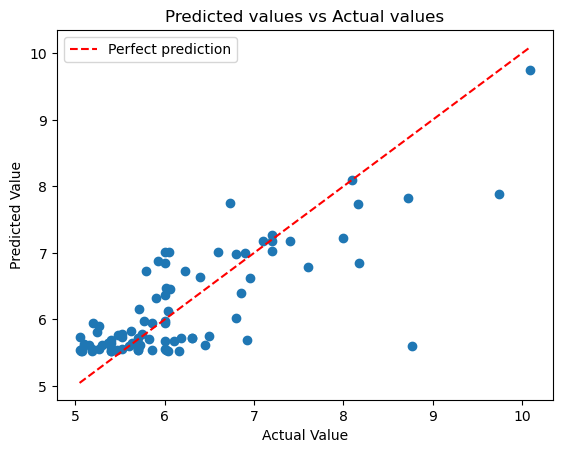

In [28]:
#Model evaluation Predicted vs Actual 

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Predicted values vs Actual values')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
plt.legend()
plt.show()

# Results

## Statistical Analysis Overview
A random forest regression model was used to calculate and predict drug potency acting on binding and inhibiting the effects of the human $\beta_1$adrenergic receptor based on drug molecular fingerprint. For this experiement, the model was given 200 trees  with a max depth of seven. The analysis included 450 different types of drugs containing various pIC50 values where two different methods of prediction testing were used. 

The first method was a train test split method. The data was split into 80% training and 20% testing data. When testing for how well the model fits the training data, the coefficient of determination ($R^2$) obtained  was 0.9. However, when testing for how well the model predicts unseen compounds, the $R^2$ score was 0.622. The root mean square error (RMSE) obtained from the predicted values was 0.624 $pIC_{50}$ units. 

The second method was the k-fold method where the data was split into 5 equal sized groups and the model was trained on four groups, and tested on one. The individual fold  $R^2$ scores were 0.617, 0.801, 0.693, 0.730, 0.733. The average coefficient of determination score using the k-fold method was 0.715 with a  standard deviation of 0.060.

Figure 1 shows the predicted vs actual $pIC_{50}$ scatter plot for the 90 test compounds. Points cluster around the diagonal reference line particulalrly in the lower $pIC_{50}$ range (5-6), with increasing scatter observed at higher $pIC_{50}$ values. One outlier is observed at actual $pIC_{50}$ ≈ 8.7 with a predicted value of approximately 5.5. 

## Discussion

The gap between the training $R^2$(0.900) and test $R^2$ (0.622) suggest the model exhibits moderate overfitting. This occurs because the model has already seen the training data, therefore it will be more accurate when predicting something it has already seen, however, when exposed to new data (test data), it falls short when trying to predict as it is data the model has not seen before. To address this, max_depth was constrained to 7, which lowered the effect of overfitting, thus increasing predictive performance. The training $R^2$ value went from 0.942 to 0.900 while the cross-validated test performance improved. 

When applying the k-fold method, before splitting the data into 5 equal sized groups, the data was shuffled. This was done because prior to doing so, if the method proceeded in sequential order, the results would not have demonstrated high potential results. The unshuffled mean $R^2$ was 0.285 while the shuffled mean was $R^2$ 0.715. ChEMBL returns data in sequential order by activityID, meaning compounds from the same publication or structural series cluster together. Shuffling the data beforehand resulted in a less bias output, ensuring that the training data is diverse, and when confronted with the test data, a more accurate result will show.

The outliers shown in the graph represent the imperfectness of the model as shown by the $R^2$ score. One reason this may occur is due to similar molecular fingerprints between two molecules despite having different $pIC_{50}$ scores. This phenomenon, known as an activity cliff occurs when functional groups or a slight variation in the structure may shift the $pIC_{50}$ values drastically. 

The overall performance of 0.715 is not terrible, however the higher the value, the more useful the model is, especially when it comes to saving time in deciding what drug is worth testing on the receptor. The primary practical utility of this model is to show the relative potency of many drugs which is shown in the positive correlation in the graph. A model with $R^2$ = 0.715 is useful for prioritizing which compounds to test in a wet lab, even if it cant predict exact values perfectly.

## Conclusion

The model demonstrated satisfactory results with room for improvement. The cross validation score $R^2$ 0.715 suggest that the model explains 71.5% of the variation in the actual $pIC_{50}$ scores. While the model showed signs of moderate overfitting as evidence by the gap between training $R^2$ (0.900) and test $R^2$ (0.622), hyperparameter tuning reduced this effect.
This project can be used for prioritizing drugs in wet lab compound testing which saves time and resources. The positive correlation in figure 1 supports this use case as the ranking ability is what makes it useful for prioritization.
More published experiments will lead to more data, resulting in a better model and better predictions which leads to more targeted experiements and more data, creating a system that essentially feeds itself and gets more effective the more its being used.

## Future Work

Several improvements could be made to enhance the predictive performance of this model.

### Better Algorithms
First, alternative machine learning algorithms such as XGBoost or Graph Neural networks could be explored. Unlike Random Forest, these methods may capture more complex relationships within the data. XGBoost builds decision trees similar to that of Random Forest, however, each new tree corrects the errors of the previous one unlike Random Forest where each tree makes its own prediction and the forest averages them. Graph Neural Networks may even be better as instead of generating fingerprints, each molecule is represented as graphs of atoms and bonds, exposing the model to its unique structure rather than predefined molecular fingerprints.

### More data
Expanding the training dataset would likely improve model performance. The current dataset of 450 compounds is relatively small for machine learning applications when attempting to predict $pIC_{50}$ values. Incorporating additional compounds with reliable experimental $pIC_{50}$ measurements could potentially improve its ability to generalize previously unseen compounds and reduce the risk of overfitting.

### Additional Descriptors
Supplementing Morgan fingerprints with additional molecular descriptors such as molecular weight, lipophilicity, hydrogen bond donors and acceptors and surface area could provide the model with additional chemical information beyond structural features alone, leading to a potentially more accurate result.

In [31]:
with open('beta1_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("Final model saved successfully")

Final model saved successfully
